In [ ]:
import pandas as pd

In [ ]:
# Carga de cada Excel en un DataFrame
df_paro_prov_raw = pd.read_excel("tasaParoProvincias2025.xlsx")
df_poblacion_prov_raw = pd.read_excel("poblacionProvincias2025.xlsx")
df_mayores65_prov_raw = pd.read_excel("personasMayores65Provincias2025.xlsx")
df_renta_prov_raw = pd.read_excel("rentaNetaMediaHogarProvincias2023.xlsx")
df_pib_prov_raw = pd.read_excel("pibProvincias2023.xlsx")
df_pib_capita_prov_raw = pd.read_excel("pibPerCapitaProvincias2023.xlsx")
df_dependencia_prov_raw = pd.read_excel("tasaDependenciaProvincia2025.xlsx")
df_esperanza_vida_prov_raw = pd.read_excel("esperanzaVidaNacerProvincias2024.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

## Transformaciones DFs

In [ ]:
df_paro_prov = df_paro_prov_raw.iloc[8:60].copy()
df_paro_prov = df_paro_prov.iloc[:, :5]
df_paro_prov.columns = [
    "Provincia",
    "T4",
    "T3",
    "T2",
    "T1"
]

# Comunidad Autónoma como texto
df_paro_prov["Provincia"] = df_paro_prov["Provincia"].astype(str)

# Trimestres como float
for col in ["T4", "T3", "T2", "T1"]:
    df_paro_prov[col] = pd.to_numeric(df_paro_prov[col], errors="coerce")


# Calcular media anual
df_paro_prov["Paro_medio"] = df_paro_prov[["T4", "T3", "T2", "T1"]].mean(axis=1)
df_paro_prov["Paro_medio"] = df_paro_prov["Paro_medio"].round(2)
df_paro_prov = df_paro_prov[["Provincia", "Paro_medio"]]

# Asegurar tipo float
df_paro_prov["Paro_medio"] = df_paro_prov["Paro_medio"].astype(float)


# Mostrar las primeras filas de cada uno
print("=== PARO ===")
display(df_paro_prov)
df_paro_prov.dtypes

=== PARO ===


,Provincia,Paro_medio
8,02 Albacete,11.31
9,03 Alicante/Alacant,12.51
10,04 Almería,13.86
11,01 Araba/Álava,7.20
12,33 Asturias,8.83
13,05 Ávila,8.88
14,06 Badajoz,14.38
15,"07 Balears, Illes",8.94
16,08 Barcelona,8.20
17,48 Bizkaia,7.76


,0
Provincia,object
Paro_medio,float64


In [ ]:
df_poblacion_prov = df_poblacion_prov_raw.iloc[7:59, :2].copy()
df_poblacion_prov.columns = [
    "Provincia",
    "Poblacion"
]

df_poblacion_prov["Provincia"] = df_poblacion_prov["Provincia"].astype(str)
df_poblacion_prov["Poblacion"] = df_poblacion_prov["Poblacion"].astype("int64")

print("=== POBLACIÓN ===")
display(df_poblacion_prov)
df_poblacion_prov.dtypes

=== POBLACIÓN ===


,Provincia,Poblacion
7,04 Almería,770554
8,11 Cádiz,1261420
9,14 Córdoba,773163
10,18 Granada,945797
11,21 Huelva,538789
12,23 Jaén,618143
13,29 Málaga,1791183
14,41 Sevilla,1977664
15,22 Huesca,230087
16,44 Teruel,136091


,0
Provincia,object
Poblacion,int64


In [ ]:
df_mayores65_prov = df_mayores65_prov_raw.iloc[7:59, :2].copy()

df_mayores65_prov.columns = [
    "Provincia",
    "Porcentaje_Mayores_65"
]

# Tipos
df_mayores65_prov["Provincia"] = (
    df_mayores65_prov["Provincia"]
    .astype(str)
)

df_mayores65_prov["Porcentaje_Mayores_65"] = (
    pd.to_numeric(
        df_mayores65_prov["Porcentaje_Mayores_65"],
        errors="coerce"
    )
    .astype(float)
)

print("=== MAYORES DE 65 ===")
display(df_mayores65_prov)

df_mayores65_prov.info()

=== MAYORES DE 65 ===


,Provincia,Porcentaje_Mayores_65
7,02 Albacete,20.84
8,03 Alicante/Alacant,20.96
9,04 Almería,16.31
10,01 Araba/Álava,22.85
11,33 Asturias,28.36
12,05 Ávila,27.19
13,06 Badajoz,21.52
14,"07 Balears, Illes",16.84
15,08 Barcelona,19.70
16,48 Bizkaia,24.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 7 to 58
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Provincia              52 non-null     object 
 1   Porcentaje_Mayores_65  52 non-null     float64
dtypes: float64(1), object(1)
memory usage: 964.0+ bytes


In [ ]:
df_renta_prov = df_renta_prov_raw.iloc[7:59, :2].copy()

df_renta_prov.columns = [
    "Provincia",
    "Renta_Media_Hogar"
]

df_renta_prov["Provincia"] = df_renta_prov["Provincia"].astype(str)

df_renta_prov["Renta_Media_Hogar"] = pd.to_numeric(
    df_renta_prov["Renta_Media_Hogar"],
    errors="coerce"
).astype("int64")

print("=== RENTA ===")
display(df_renta_prov)

df_renta_prov.info()

=== RENTA ===


,Provincia,Renta_Media_Hogar
7,04 Almería,30936
8,11 Cádiz,32323
9,14 Córdoba,30917
10,18 Granada,31314
11,21 Huelva,31066
12,23 Jaén,29119
13,29 Málaga,33868
14,41 Sevilla,34269
15,22 Huesca,37009
16,44 Teruel,34725


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 7 to 58
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Provincia          52 non-null     object
 1   Renta_Media_Hogar  52 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 964.0+ bytes


In [ ]:
df_pib_prov = df_pib_prov_raw.iloc[5:59, :2].copy()

df_pib_prov.columns = [
    "Provincia",
    "PIB"
]

df_pib_prov["Provincia"] = df_pib_prov["Provincia"].astype(str)

# Pasamos de miles de € a millones de €
df_pib_prov["PIB"] = (df_pib_prov["PIB"] / 1000).round(3)

df_pib_prov["PIB"] = pd.to_numeric(
    df_pib_prov["PIB"],
    errors="coerce"
).astype("int64")

print("=== PIB ===")
display(df_pib_prov)

df_pib_prov.info()

=== PIB ===


,Provincia,PIB
5,04 Almería,18250
6,11 Cádiz,26783
7,14 Córdoba,17217
8,18 Granada,20836
9,21 Huelva,13183
10,23 Jaén,13052
11,29 Málaga,41235
12,41 Sevilla,48846
13,22 Huesca,8167
14,44 Teruel,4324


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 5 to 56
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Provincia  52 non-null     object
 1   PIB        52 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 964.0+ bytes


In [ ]:
df_pib_capita_prov = df_pib_capita_prov_raw.iloc[5:59, :2].copy()

df_pib_capita_prov.columns = [
    "Provincia",
    "PIB_Per_Capita"
]

df_pib_capita_prov["Provincia"] = (
    df_pib_capita_prov["Provincia"]
    .astype(str)
)

df_pib_capita_prov["PIB_Per_Capita"] = pd.to_numeric(
    df_pib_capita_prov["PIB_Per_Capita"],
    errors="coerce"
).astype("int64")

print("=== PIB PER CAPITA ===")
display(df_pib_capita_prov)

df_pib_capita_prov.info()

=== PIB PER CAPITA ===


,Provincia,PIB_Per_Capita
5,04 Almería,24103
6,11 Cádiz,21311
7,14 Córdoba,22226
8,18 Granada,22240
9,21 Huelva,24647
10,23 Jaén,21057
11,29 Málaga,23380
12,41 Sevilla,24871
13,22 Huesca,35871
14,44 Teruel,31989


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 5 to 56
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provincia       52 non-null     object
 1   PIB_Per_Capita  52 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 964.0+ bytes


In [ ]:
df_dependencia_prov = df_dependencia_prov_raw.iloc[6:58, :2].copy()

df_dependencia_prov.columns = [
    "Provincia",
    "Tasa_Dependencia"
]

df_dependencia_prov["Provincia"] = (
    df_dependencia_prov["Provincia"]
    .astype(str)
)

df_dependencia_prov["Tasa_Dependencia"] = pd.to_numeric(
    df_dependencia_prov["Tasa_Dependencia"],
    errors="coerce"
).astype("float64")

print("=== DEPENDENCIA ===")
display(df_dependencia_prov)

df_dependencia_prov.info()

=== DEPENDENCIA ===


,Provincia,Tasa_Dependencia
6,02 Albacete,53.40
7,03 Alicante/Alacant,54.62
8,04 Almería,49.42
9,01 Araba/Álava,59.08
10,33 Asturias,64.07
11,05 Ávila,65.15
12,06 Badajoz,54.99
13,"07 Balears, Illes",45.33
14,08 Barcelona,51.16
15,48 Bizkaia,59.32


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 6 to 57
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Provincia         52 non-null     object 
 1   Tasa_Dependencia  52 non-null     float64
dtypes: float64(1), object(1)
memory usage: 964.0+ bytes


In [ ]:
df_esperanza_vida_prov = df_esperanza_vida_prov_raw.iloc[7:59, :2].copy()

df_esperanza_vida_prov.columns = [
    "Provincia",
    "Esperanza_Vida"
]

df_esperanza_vida_prov["Provincia"] = (
    df_esperanza_vida_prov["Provincia"]
    .astype(str)
)

df_esperanza_vida_prov["Esperanza_Vida"] = pd.to_numeric(
    df_esperanza_vida_prov["Esperanza_Vida"],
    errors="coerce"
).astype("float64")

print("=== ESPERANZA DE VIDA ===")
display(df_esperanza_vida_prov)

df_esperanza_vida_prov.info()

=== ESPERANZA DE VIDA ===


,Provincia,Esperanza_Vida
7,02 Albacete,83.66
8,03 Alicante/Alacant,83.61
9,04 Almería,82.10
10,01 Araba/Álava,85.02
11,33 Asturias,83.32
12,05 Ávila,84.45
13,06 Badajoz,82.83
14,"07 Balears, Illes",83.46
15,08 Barcelona,84.45
16,48 Bizkaia,84.64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 7 to 58
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Provincia       52 non-null     object 
 1   Esperanza_Vida  52 non-null     float64
dtypes: float64(1), object(1)
memory usage: 964.0+ bytes


### DF de superficie de Provincias (km2)

In [ ]:
df_extension_prov = pd.DataFrame({
    "Provincia": [
        "01 Araba/Álava",
        "02 Albacete",
        "03 Alicante/Alacant",
        "04 Almería",
        "05 Ávila",
        "06 Badajoz",
        "07 Balears, Illes",
        "08 Barcelona",
        "09 Burgos",
        "10 Cáceres",
        "11 Cádiz",
        "12 Castellón/Castelló",
        "13 Ciudad Real",
        "14 Córdoba",
        "15 Coruña, A",
        "16 Cuenca",
        "17 Girona",
        "18 Granada",
        "19 Guadalajara",
        "20 Gipuzkoa",
        "21 Huelva",
        "22 Huesca",
        "23 Jaén",
        "24 León",
        "25 Lleida",
        "26 Rioja, La",
        "27 Lugo",
        "28 Madrid",
        "29 Málaga",
        "30 Murcia",
        "31 Navarra",
        "32 Ourense",
        "33 Asturias",
        "34 Palencia",
        "35 Palmas, Las",
        "36 Pontevedra",
        "37 Salamanca",
        "38 Santa Cruz de Tenerife",
        "39 Cantabria",
        "40 Segovia",
        "41 Sevilla",
        "42 Soria",
        "43 Tarragona",
        "44 Teruel",
        "45 Toledo",
        "46 Valencia/València",
        "47 Valladolid",
        "48 Bizkaia",
        "49 Zamora",
        "50 Zaragoza",
        "51 Ceuta",
        "52 Melilla"
    ],
    "Extension_km2": [
        3037,   # Álava
        14926,  # Albacete
        5817,   # Alicante
        8775,   # Almería
        8051,   # Ávila
        21766,  # Badajoz
        4992,   # Baleares
        7728,   # Barcelona
        14292,  # Burgos
        19868,  # Cáceres
        7440,   # Cádiz
        6662,   # Castellón
        19813,  # Ciudad Real
        13771,  # Córdoba
        7951,   # Coruña
        17140,  # Cuenca
        5910,   # Girona
        12647,  # Granada
        12214,  # Guadalajara
        1980,   # Gipuzkoa
        10128,  # Huelva
        15636,  # Huesca
        13496,  # Jaén
        15581,  # León
        12172,  # Lleida
        5045,   # La Rioja
        9856,   # Lugo
        8028,   # Madrid
        7306,   # Málaga
        11314,  # Murcia
        10391,  # Navarra
        7273,   # Ourense
        10604,  # Asturias
        8052,   # Palencia
        4066,   # Las Palmas
        4495,   # Pontevedra
        12350,  # Salamanca
        3381,   # Santa Cruz de Tenerife
        5321,   # Cantabria
        6921,   # Segovia
        14036,  # Sevilla
        10306,  # Soria
        6303,   # Tarragona
        14810,  # Teruel
        15370,  # Toledo
        10776,  # Valencia
        8111,   # Valladolid
        2217,   # Bizkaia
        10561,  # Zamora
        17274,  # Zaragoza
        20,     # Ceuta
        12      # Melilla
    ]
})

df_extension_prov.info()
display(df_extension_prov)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Provincia      52 non-null     object
 1   Extension_km2  52 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 964.0+ bytes


,Provincia,Extension_km2
0,01 Araba/Álava,3037
1,02 Albacete,14926
2,03 Alicante/Alacant,5817
3,04 Almería,8775
4,05 Ávila,8051
5,06 Badajoz,21766
6,"07 Balears, Illes",4992
7,08 Barcelona,7728
8,09 Burgos,14292
9,10 Cáceres,19868


### Unidades de los indicadores

| Indicador | Unidad |
|------------|----------|
| Poblacion | Personas |
| Paro_medio | % |
| Porcentaje_Mayores_65 | % |
| Tasa_Dependencia | % |
| Esperanza_Vida | Años |
| Renta_Media_Hogar | Euros |
| PIB | Millones de Euros |
| PIB_Per_Capita | Euros por habitante |
| Extension_km2 | km² |
| Densidad_Poblacion | Habitantes/km² |

# DF final

In [ ]:
from functools import reduce

def limpiar_provincia(df):
    df = df.copy()

    df["Provincia"] = (
        df["Provincia"]
        .astype(str)
        .str.replace("\xa0", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return df

# Limpiar todos los dataframes
df_poblacion_prov = limpiar_provincia(df_poblacion_prov)
df_paro_prov = limpiar_provincia(df_paro_prov)
df_mayores65_prov = limpiar_provincia(df_mayores65_prov)
df_renta_prov = limpiar_provincia(df_renta_prov)
df_pib_prov = limpiar_provincia(df_pib_prov)
df_pib_capita_prov = limpiar_provincia(df_pib_capita_prov)
df_dependencia_prov = limpiar_provincia(df_dependencia_prov)
df_esperanza_vida_prov = limpiar_provincia(df_esperanza_vida_prov)
df_extension_prov = limpiar_provincia(df_extension_prov)

# Lista de dataframes
dfs = [
    df_poblacion_prov,
    df_paro_prov,
    df_mayores65_prov,
    df_renta_prov,
    df_pib_prov,
    df_pib_capita_prov,
    df_extension_prov,
    df_esperanza_vida_prov,
    df_dependencia_prov
]

# Merge final
df_final = reduce(
    lambda left, right: pd.merge(left, right, on="Provincia", how="inner"),
    dfs
)

# Densidad de población
df_final["Densidad_Poblacion"] = (
    df_final["Poblacion"] /
    df_final["Extension_km2"]
).round(2)

# Ordenar por código de provincia
df_final = df_final.sort_values("Provincia").reset_index(drop=True)

# Nombre sin código
df_final["Nombre_Completo"] = (
    df_final["Provincia"]
    .str.replace(r"^\d+\s+", "", regex=True)
    .str.strip()
)

print("=== DATASET FINAL ===")
display(df_final)

print("\nDimensiones:")
print(df_final.shape)

print("\nTipos:")
print(df_final.dtypes)

=== DATASET FINAL ===


,Provincia,Poblacion,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB,PIB_Per_Capita,Extension_km2,Esperanza_Vida,Tasa_Dependencia,Densidad_Poblacion,Nombre_Completo
0,01 Araba/Álava,341961,7.20,22.85,41914,14090,41756,3037,85.02,59.08,112.60,Araba/Álava
1,02 Albacete,390751,11.31,20.84,32600,10285,26488,14926,83.66,53.40,26.18,Albacete
2,03 Alicante/Alacant,2033566,12.51,20.96,31507,46472,23539,5817,83.61,54.62,349.59,Alicante/Alacant
3,04 Almería,770554,13.86,16.31,30936,18250,24103,8775,82.10,49.42,87.81,Almería
4,05 Ávila,160738,8.88,27.19,30159,3726,23275,8051,84.45,65.15,19.96,Ávila
5,06 Badajoz,665155,14.38,21.52,29231,14927,22412,21766,82.83,54.99,30.56,Badajoz
6,"07 Balears, Illes",1249844,8.94,16.84,44812,41502,33995,4992,83.46,45.33,250.37,"Balears, Illes"
7,08 Barcelona,5959941,8.20,19.70,44243,209563,35899,7728,84.45,51.16,771.21,Barcelona
8,09 Burgos,362663,7.60,25.61,36605,11303,31527,14292,84.56,61.97,25.38,Burgos
9,10 Cáceres,388190,15.44,25.36,28614,10265,26427,19868,83.62,60.03,19.54,Cáceres



Dimensiones:
(52, 12)

Tipos:
Provincia                 object
Poblacion                  int64
Paro_medio               float64
Porcentaje_Mayores_65    float64
Renta_Media_Hogar          int64
PIB                        int64
PIB_Per_Capita             int64
Extension_km2              int64
Esperanza_Vida           float64
Tasa_Dependencia         float64
Densidad_Poblacion       float64
Nombre_Completo           object
dtype: object


# Operaciones

In [ ]:
# Comprobación del dataset
df = df_final.copy()

display(df)
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

,Provincia,Poblacion,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB,PIB_Per_Capita,Extension_km2,Esperanza_Vida,Tasa_Dependencia,Densidad_Poblacion,Nombre_Completo
0,01 Araba/Álava,341961,7.20,22.85,41914,14090,41756,3037,85.02,59.08,112.60,Araba/Álava
1,02 Albacete,390751,11.31,20.84,32600,10285,26488,14926,83.66,53.40,26.18,Albacete
2,03 Alicante/Alacant,2033566,12.51,20.96,31507,46472,23539,5817,83.61,54.62,349.59,Alicante/Alacant
3,04 Almería,770554,13.86,16.31,30936,18250,24103,8775,82.10,49.42,87.81,Almería
4,05 Ávila,160738,8.88,27.19,30159,3726,23275,8051,84.45,65.15,19.96,Ávila
5,06 Badajoz,665155,14.38,21.52,29231,14927,22412,21766,82.83,54.99,30.56,Badajoz
6,"07 Balears, Illes",1249844,8.94,16.84,44812,41502,33995,4992,83.46,45.33,250.37,"Balears, Illes"
7,08 Barcelona,5959941,8.20,19.70,44243,209563,35899,7728,84.45,51.16,771.21,Barcelona
8,09 Burgos,362663,7.60,25.61,36605,11303,31527,14292,84.56,61.97,25.38,Burgos
9,10 Cáceres,388190,15.44,25.36,28614,10265,26427,19868,83.62,60.03,19.54,Cáceres


(52, 12)
Provincia                 object
Poblacion                  int64
Paro_medio               float64
Porcentaje_Mayores_65    float64
Renta_Media_Hogar          int64
PIB                        int64
PIB_Per_Capita             int64
Extension_km2              int64
Esperanza_Vida           float64
Tasa_Dependencia         float64
Densidad_Poblacion       float64
Nombre_Completo           object
dtype: object
Provincia                0
Poblacion                0
Paro_medio               0
Porcentaje_Mayores_65    0
Renta_Media_Hogar        0
PIB                      0
PIB_Per_Capita           0
Extension_km2            0
Esperanza_Vida           0
Tasa_Dependencia         0
Densidad_Poblacion       0
Nombre_Completo          0
dtype: int64


A partir del dataset integrado se diferencian dos conjuntos de variables.

1. En primer lugar, se mantienen **variables descriptivas generales**, incluyendo población, PIB, superficie y densidad, que permiten caracterizar el tamaño y la estructura territorial de cada provincia.

2. En segundo lugar, para las técnicas multivariantes —PCA y clustering— se seleccionan únicamente **variables relativas o de intensidad territorial**. Se excluyen población, PIB agregado y superficie, ya que son variables de escala que podrían sesgar el análisis hacia las provincias de mayor tamaño demográfico o económico.

Esta separación permite combinar una descripción territorial completa con un análisis comparativo más equilibrado entre territorios.

In [ ]:
# Variables descriptivas generales
cols_descriptivas = [
    "Poblacion",
    "PIB",
    "Extension_km2",
    "Densidad_Poblacion",
    "Paro_medio",
    "Porcentaje_Mayores_65",
    "Renta_Media_Hogar",
    "PIB_Per_Capita",
    "Tasa_Dependencia",
    "Esperanza_Vida"
]

# Variables para PCA y clustering
cols_modelo = [
    "Paro_medio",
    "Porcentaje_Mayores_65",
    "Renta_Media_Hogar",
    "PIB_Per_Capita",
    "Tasa_Dependencia",
    "Densidad_Poblacion",
    "Esperanza_Vida"
]

df_desc = df[cols_descriptivas].copy()
df_modelo = df[cols_modelo].copy()

print("Variables descriptivas:")
print(cols_descriptivas)

print("\nVariables usadas en PCA y clustering:")
print(cols_modelo)

display(df_modelo)

df_num = df_modelo.copy()

Variables descriptivas:
['Poblacion', 'PIB', 'Extension_km2', 'Densidad_Poblacion', 'Paro_medio', 'Porcentaje_Mayores_65', 'Renta_Media_Hogar', 'PIB_Per_Capita', 'Tasa_Dependencia', 'Esperanza_Vida']

Variables usadas en PCA y clustering:
['Paro_medio', 'Porcentaje_Mayores_65', 'Renta_Media_Hogar', 'PIB_Per_Capita', 'Tasa_Dependencia', 'Densidad_Poblacion', 'Esperanza_Vida']


,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
0,7.20,22.85,41914,41756,59.08,112.60,85.02
1,11.31,20.84,32600,26488,53.40,26.18,83.66
2,12.51,20.96,31507,23539,54.62,349.59,83.61
3,13.86,16.31,30936,24103,49.42,87.81,82.10
4,8.88,27.19,30159,23275,65.15,19.96,84.45
5,14.38,21.52,29231,22412,54.99,30.56,82.83
6,8.94,16.84,44812,33995,45.33,250.37,83.46
7,8.20,19.70,44243,35899,51.16,771.21,84.45
8,7.60,25.61,36605,31527,61.97,25.38,84.56
9,15.44,25.36,28614,26427,60.03,19.54,83.62


## Estadísticos descriptivos

En primer lugar, se calculan estadísticos descriptivos básicos para cada indicador: media, desviación típica, valores mínimo y máximo, mediana y cuartiles. Este análisis permite obtener una primera aproximación a la dispersión de los datos y detectar variables con diferencias territoriales especialmente acusadas entre provincias.

In [ ]:
# Comprobación del dataset
resumen = df_desc.describe().T
display(resumen)

,count,mean,std,min,25%,50%,75%,max
Poblacion,52.0,944774.942308,1.264997e+06,83567.00,326607.7500,622881.500,1.033176e+06,7113886.00
PIB,52.0,28776.115385,4.834925e+04,1753.00,9554.5000,16582.500,2.860950e+04,295939.00
Extension_km2,52.0,9730.615385,5.101404e+03,12.00,6204.7500,9315.500,1.356475e+04,21766.00
Densidad_Poblacion,52.0,351.122692,1.139742e+03,8.75,26.4875,65.495,1.798775e+02,7255.58
Paro_medio,52.0,11.009038,4.309381e+00,5.20,7.7525,10.075,1.325000e+01,24.82
Porcentaje_Mayores_65,52.0,22.252885,4.399546e+00,12.68,19.1475,21.555,2.482500e+01,32.67
Renta_Media_Hogar,52.0,35855.942308,5.009071e+03,28614.00,32119.0000,35385.500,3.722475e+04,48806.00
PIB_Per_Capita,52.0,28828.557692,5.561376e+03,20454.00,24322.5000,28200.000,3.209475e+04,42639.00
Tasa_Dependencia,52.0,56.438846,6.842912e+00,42.14,51.1325,55.495,6.044250e+01,73.39
Esperanza_Vida,52.0,83.770577,8.714005e-01,81.60,83.2475,83.855,8.445000e+01,85.77


Los estadísticos descriptivos muestran una elevada heterogeneidad entre provincias españolas. Variables como la población, el PIB y la densidad de población presentan una gran dispersión, debido a la coexistencia de provincias altamente urbanizadas y densamente pobladas con otras de carácter predominantemente rural y baja densidad demográfica.

También se observan diferencias relevantes en indicadores socioeconómicos como el PIB per cápita, la renta media por hogar, la tasa de paro o la esperanza de vida, lo que confirma la existencia de contrastes territoriales significativos a escala provincial.

Estas diferencias sugieren que la escala autonómica puede ocultar situaciones internas diversas, reforzando el interés de realizar un análisis complementario a nivel provincial.

## Rankings territoriales por indicador



In [ ]:
# Ranking por variable
for col in cols_descriptivas:
    print(f"\n=== TOP 5 {col} ===")
    display(df[["Nombre_Completo", col]].sort_values(col, ascending=False).head(5))

    print(f"\n=== BOTTOM 5 {col} ===")
    display(df[["Nombre_Completo", col]].sort_values(col, ascending=True).head(5))


=== TOP 5 Poblacion ===


,Nombre_Completo,Poblacion
27,Madrid,7113886
7,Barcelona,5959941
45,Valencia/València,2763996
2,Alicante/Alacant,2033566
40,Sevilla,1977664



=== BOTTOM 5 Poblacion ===


,Nombre_Completo,Poblacion
50,Ceuta,83567
51,Melilla,87067
41,Soria,90183
43,Teruel,136091
39,Segovia,158251



=== TOP 5 PIB ===


...

,Nombre_Completo,Tasa_Dependencia
34,"Palmas, Las",42.14
37,Santa Cruz de Tenerife,45.18
6,"Balears, Illes",45.33
50,Ceuta,47.20
18,Guadalajara,48.16



=== TOP 5 Esperanza_Vida ===


,Nombre_Completo,Esperanza_Vida
36,Salamanca,85.77
27,Madrid,85.58
39,Segovia,85.30
0,Araba/Álava,85.02
46,Valladolid,85.02



=== BOTTOM 5 Esperanza_Vida ===


,Nombre_Completo,Esperanza_Vida
50,Ceuta,81.60
3,Almería,82.10
20,Huelva,82.42
10,Cádiz,82.55
51,Melilla,82.66


Los rankings permiten identificar de forma directa las provincias que presentan los valores más elevados y más reducidos para cada indicador analizado.

En términos demográficos, Madrid y Barcelona destacan como las provincias más pobladas, mientras que Soria, Teruel y Segovia aparecen entre las menos pobladas del conjunto analizado. Asimismo, Soria, Teruel, Cuenca, Huesca y Zamora registran las menores densidades de población, reflejando algunos de los casos más representativos de despoblación y dispersión territorial en España.

Desde el punto de vista económico, Madrid, Barcelona y Valencia concentran los mayores niveles de PIB agregado, mientras que Madrid, las provincias vascas y Navarra presentan los valores más elevados de PIB per cápita. Por el contrario, Jaén, Cádiz, Córdoba y Granada aparecen entre las provincias con menor PIB per cápita, evidenciando situaciones de menor dinamismo económico relativo.

Los indicadores demográficos muestran también contrastes muy marcados. Zamora, Ourense, Lugo, León y Salamanca presentan los mayores porcentajes de población mayor de 65 años y las tasas de dependencia más elevadas, configurando un perfil caracterizado por el envejecimiento y la pérdida de población en edad activa.

Resulta especialmente relevante observar que algunas provincias tradicionalmente asociadas al debate sobre la despoblación, como Soria o Teruel, destacan principalmente por sus características demográficas, mientras que otras como Jaén aparecen más vinculadas a indicadores económicos y laborales desfavorables. Este resultado sugiere que los desequilibrios territoriales existentes en España responden a realidades diversas que no pueden explicarse únicamente mediante el fenómeno de la despoblación.

En conjunto, estos resultados ponen de manifiesto la elevada heterogeneidad existente entre provincias españolas y justifican la aplicación posterior de técnicas multivariantes para identificar patrones territoriales comunes.

## Matriz de correlación

Para estudiar las relaciones entre los distintos indicadores se calcula una matriz de correlación de Pearson. Esta matriz permite identificar asociaciones positivas o negativas entre variables y detectar posibles patrones conjuntos entre dimensiones económicas, demográficas y sociales.

El análisis de correlaciones resulta especialmente útil como paso previo al PCA, ya que permite comprobar si existen variables que evolucionan conjuntamente y, por tanto, pueden resumirse mediante componentes sintéticos.

In [ ]:
# Correlaciones
corr = df_num.corr(method="pearson")
display(corr)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Paro_medio,1.000000,-0.550117,-0.151818,-0.720807,-0.460034,0.597604,-0.727523
Porcentaje_Mayores_65,-0.550117,1.000000,-0.356954,0.211318,0.947355,-0.446548,0.504236
Renta_Media_Hogar,-0.151818,-0.356954,1.000000,0.626661,-0.296174,0.469063,0.251984
PIB_Per_Capita,-0.720807,0.211318,0.626661,1.000000,0.202309,-0.205601,0.629958
Tasa_Dependencia,-0.460034,0.947355,-0.296174,0.202309,1.000000,-0.253129,0.492272
Densidad_Poblacion,0.597604,-0.446548,0.469063,-0.205601,-0.253129,1.000000,-0.307137
Esperanza_Vida,-0.727523,0.504236,0.251984,0.629958,0.492272,-0.307137,1.000000


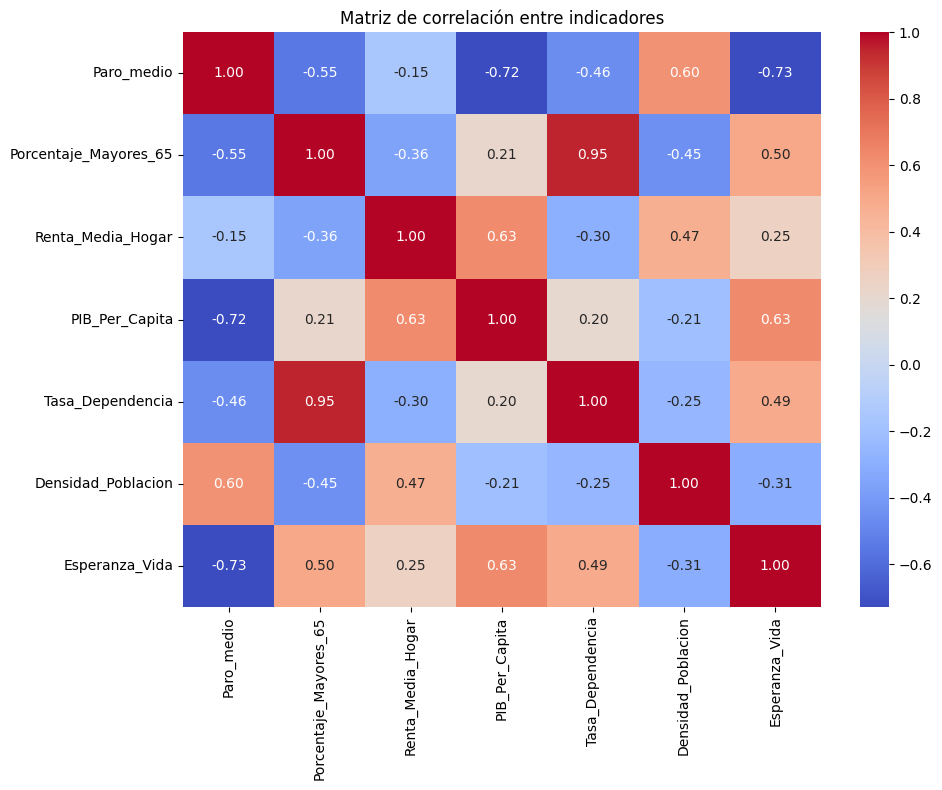

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre indicadores")
plt.tight_layout()
plt.show()

La matriz de correlación muestra relaciones significativas entre varios de los indicadores analizados. Destaca especialmente la fuerte correlación positiva entre el porcentaje de población mayor de 65 años y la tasa de dependencia (0,95), lo que confirma la estrecha relación existente entre envejecimiento demográfico y presión sobre la población en edad de trabajar.

Desde el punto de vista económico, el PIB per cápita presenta una correlación positiva con la renta media por hogar (0,63) y con la esperanza de vida (0,63), mientras que mantiene una relación negativa con la tasa de paro (-0,72). Estos resultados sugieren que las provincias con mayor nivel de desarrollo económico tienden a registrar mejores condiciones laborales y mayores niveles de bienestar.

La tasa de paro aparece asimismo negativamente relacionada con la esperanza de vida (-0,73), constituyendo una de las asociaciones más intensas observadas en el conjunto de datos. Este resultado apunta a una posible conexión entre situación socioeconómica y condiciones generales de vida de la población.

En el ámbito demográfico, la densidad de población presenta una relación negativa con el envejecimiento (-0,45) y con la tasa de dependencia (-0,25), indicando que las provincias menos densamente pobladas tienden a mostrar estructuras demográficas más envejecidas.

En conjunto, las correlaciones observadas reflejan la existencia de patrones territoriales complejos en los que factores económicos, laborales y demográficos aparecen estrechamente interrelacionados. Estos resultados justifican la aplicación posterior de técnicas de reducción de dimensionalidad y agrupamiento para identificar tipologías provinciales comunes.

## Normalización de variables

Los indicadores seleccionados presentan escalas y unidades de medida muy diferentes. Por ejemplo, la tasa de paro se expresa en porcentaje, mientras que la renta media del hogar se mide en euros. Estas diferencias de escala pueden provocar que algunas variables dominen artificialmente el análisis.

Para evitar que las variables con valores absolutos más elevados dominen el análisis estadístico, se aplicó una normalización mediante estandarización (StandardScaler). Este procedimiento transforma cada variable para que tenga media cero y desviación típica uno.

La normalización resulta especialmente necesaria para la aplicación posterior de técnicas multivariantes como el análisis de componentes principales (PCA) y los algoritmos de agrupamiento.

In [ ]:
# Normalización
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

df_scaled = pd.DataFrame(
    X_scaled,
    columns=cols_modelo,
    index=df["Nombre_Completo"]
)

display(df_scaled.round(3))

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Nombre_Completo,,,,,,,
Araba/Álava,-0.893,0.137,1.221,2.347,0.390,-0.211,1.448
Albacete,0.071,-0.324,-0.656,-0.425,-0.448,-0.288,-0.128
Alicante/Alacant,0.352,-0.297,-0.877,-0.960,-0.268,-0.001,-0.186
Almería,0.668,-1.364,-0.992,-0.858,-1.036,-0.233,-1.936
Ávila,-0.499,1.133,-1.148,-1.008,1.285,-0.293,0.787
Badajoz,0.790,-0.168,-1.335,-1.165,-0.214,-0.284,-1.090
"Balears, Illes",-0.485,-1.242,1.805,0.938,-1.639,-0.089,-0.360
Barcelona,-0.658,-0.586,1.691,1.284,-0.779,0.372,0.787
Burgos,-0.799,0.771,0.151,0.490,0.816,-0.289,0.915


Tras la normalización, las variables seleccionadas para el análisis multivariante presentan media cero y desviación típica uno, permitiendo compararlas en igualdad de condiciones.

## Análisis de Componentes Principales (PCA)

Con el objetivo de reducir la dimensionalidad del conjunto de datos y explorar la existencia de patrones conjuntos entre variables, se aplicó un Análisis de Componentes Principales (PCA).

Esta técnica permite transformar un conjunto de variables correlacionadas en un número menor de componentes sintéticos que concentran la mayor parte de la información contenida en los datos originales.

In [ ]:
# PCA
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(df_scaled)

varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza_explicada": pca.explained_variance_ratio_,
    "Varianza_acumulada": pca.explained_variance_ratio_.cumsum()
})

display(varianza)

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.496735,0.496735
1,PC2,0.289616,0.786351
2,PC3,0.135323,0.921673
3,PC4,0.045501,0.967174
4,PC5,0.018440,0.985615
5,PC6,0.011058,0.996673
6,PC7,0.003327,1.000000


Los resultados muestran que el primer componente principal explica aproximadamente el 49,7% de la variabilidad total del conjunto de datos. Al incorporar el segundo componente, la varianza explicada acumulada alcanza el 78,6%.

Considerando los tres primeros componentes principales, se consigue representar aproximadamente el 92,2% de la información original, lo que indica que gran parte de las diferencias existentes entre provincias puede resumirse mediante un número reducido de dimensiones sintéticas.

Aunque los tres primeros componentes explican conjuntamente más del 92% de la varianza total, se optó por representar únicamente los dos primeros componentes principales, ya que concentran cerca del 79% de la información original y permiten una visualización bidimensional fácilmente interpretable.

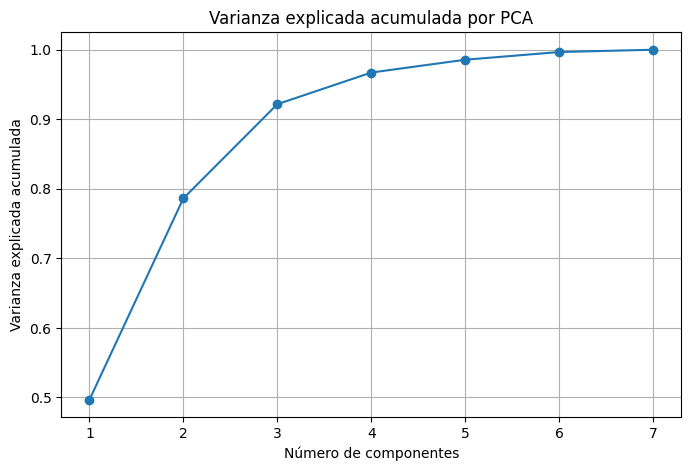

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por PCA")
plt.grid(True)
plt.show()

In [ ]:
# PCA en 2D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(df_scaled)

df_pca = pd.DataFrame({
    "Provincia": df["Nombre_Completo"],
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1]
})

display(df_pca)

,Provincia,PC1,PC2
0,Araba/Álava,-2.140702,2.215827
1,Albacete,0.460685,-0.540333
2,Alicante/Alacant,0.809290,-0.990198
3,Almería,2.394752,-0.966364
4,Ávila,-1.362903,-1.794069
5,Badajoz,1.309572,-1.790769
6,"Balears, Illes",0.806270,2.482555
7,Barcelona,-0.388153,2.528997
8,Burgos,-1.711771,0.128263
9,Cáceres,0.083134,-1.839334


El primer componente principal refleja principalmente un contraste entre provincias envejecidas y provincias más urbanizadas y dinámicas desde el punto de vista demográfico y laboral. Presenta cargas positivas en variables como la tasa de paro y la densidad de población, mientras que muestra cargas negativas en indicadores asociados al envejecimiento, la dependencia, la esperanza de vida y el PIB per cápita.

Por ello, los valores positivos de este componente tienden a asociarse a provincias más urbanas y densamente pobladas, mientras que los valores negativos se relacionan con territorios caracterizados por un mayor envejecimiento demográfico y menores densidades de población.

El segundo componente principal aparece vinculado principalmente al nivel de desarrollo económico y bienestar. Presenta cargas positivas elevadas en la renta media por hogar y en el PIB per cápita, mientras que muestra cargas negativas en indicadores asociados al envejecimiento y la dependencia demográfica.

En consecuencia, los valores elevados de este componente se asocian a provincias con mayores niveles de renta y actividad económica, mientras que los valores reducidos corresponden a territorios con menores niveles de desarrollo relativo.

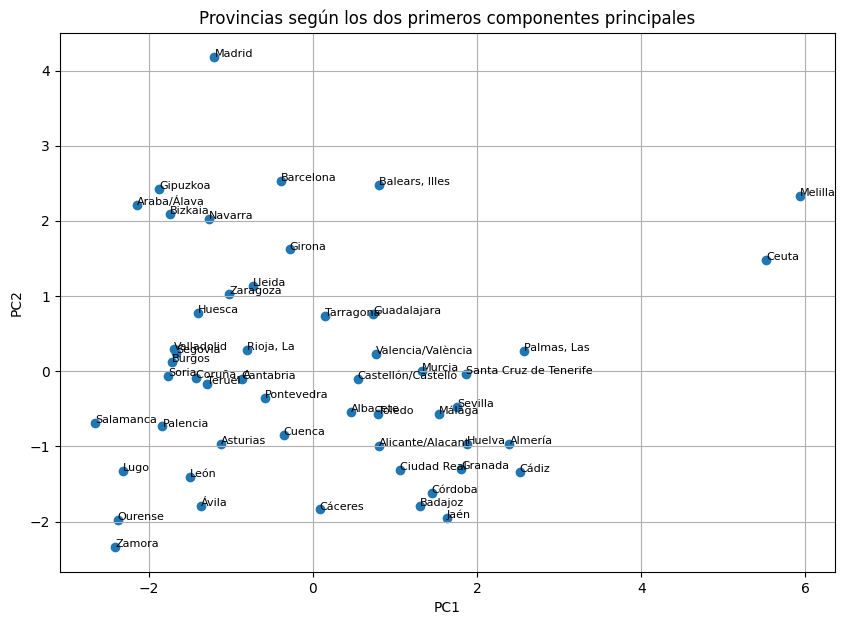

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(df_pca["PC1"], df_pca["PC2"])

for i, row in df_pca.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Provincia"], fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Provincias según los dos primeros componentes principales")
plt.grid(True)
plt.show()

In [ ]:
# Cargas de PCA
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=cols_modelo
)

display(loadings.sort_values("PC1", ascending=False))

,PC1,PC2
Paro_medio,0.478413,-0.156889
Densidad_Poblacion,0.321153,0.256881
Renta_Media_Hogar,0.011736,0.675855
PIB_Per_Capita,-0.344681,0.486077
Tasa_Dependencia,-0.406134,-0.273155
Esperanza_Vida,-0.436960,0.215869
Porcentaje_Mayores_65,-0.439500,-0.308437


La representación de las provincias en el espacio definido por los dos primeros componentes principales permite identificar patrones territoriales coherentes con los resultados observados previamente.

En la parte superior del gráfico aparecen provincias caracterizadas por elevados niveles de renta y PIB per cápita, entre las que destacan Madrid, las provincias vascas, Navarra, Barcelona y Baleares. Estas provincias constituyen algunos de los principales polos económicos del país.

En el extremo inferior se sitúan provincias con menores niveles de renta y actividad económica relativa, como Jaén, Córdoba, Badajoz, Cáceres, Zamora u Ourense.

Por otro lado, las provincias del interior y del noroeste peninsular asociadas a procesos de envejecimiento y baja densidad de población tienden a concentrarse en la zona izquierda del gráfico. Entre ellas destacan Zamora, Ourense, Lugo, León, Salamanca, Soria o Teruel.

Resulta especialmente relevante observar que provincias como Jaén aparecen alejadas del grupo formado por Soria, Teruel, Zamora u Ourense. Mientras estas últimas destacan principalmente por sus características demográficas, Jaén se sitúa más próxima a provincias con dificultades económicas y laborales. Este resultado sugiere la existencia de diferentes formas de vulnerabilidad territorial dentro de España.

Finalmente, Ceuta y Melilla aparecen claramente separadas del resto de provincias, actuando como observaciones atípicas debido a sus características demográficas, económicas y territoriales específicas.

## Biplot de componentes principales

Además de representar las provincias en el espacio definido por los dos primeros componentes principales, se construye un biplot que incorpora simultáneamente las variables originales.

Las flechas representan la dirección e intensidad de la contribución de cada variable a los componentes principales, permitiendo interpretar qué factores explican la posición relativa de cada provincia dentro del espacio factorial.

Esta representación facilita la identificación de los indicadores que más influyen en la formación de los distintos perfiles territoriales detectados mediante el PCA y el posterior análisis de clusters.

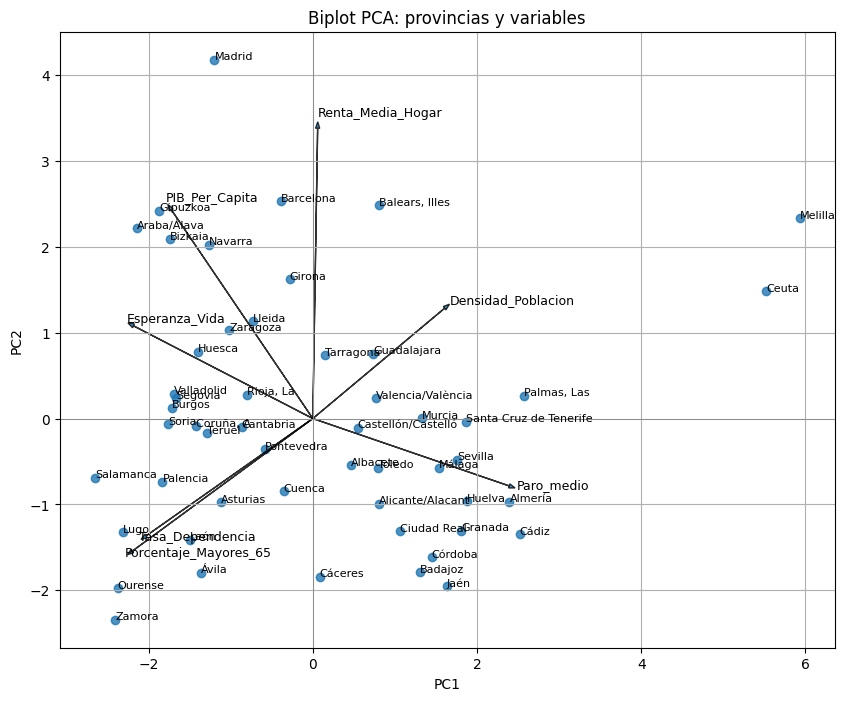

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

# Comunidades autónomas
ax.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.8
)

for _, row in df_pca.iterrows():
    ax.text(
        row["PC1"],
        row["PC2"],
        row["Provincia"],
        fontsize=8
    )

# Flechas variables
for variable in loadings.index:

    ax.arrow(
        0,
        0,
        loadings.loc[variable, "PC1"] * 5,
        loadings.loc[variable, "PC2"] * 5,
        head_width=0.05,
        alpha=0.8
    )

    ax.text(
        loadings.loc[variable, "PC1"] * 5.2,
        loadings.loc[variable, "PC2"] * 5.2,
        variable,
        fontsize=9
    )

ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

ax.set_title(
    "Biplot PCA: provincias y variables"
)

plt.grid(True)
plt.show()

El biplot permite interpretar simultáneamente la posición de las provincias y la contribución de las variables originales a los componentes principales.

Las flechas indican la dirección en la que aumenta cada indicador. Provincias situadas próximas a una determinada flecha tienden a presentar valores relativamente elevados en esa variable, mientras que provincias localizadas en la dirección opuesta presentan valores relativamente inferiores.

La representación confirma la existencia de dos grandes dimensiones territoriales. Por un lado, las variables asociadas al envejecimiento y la dependencia aparecen agrupadas y orientadas en una dirección similar, reflejando la estrecha relación observada previamente en la matriz de correlación. Por otro lado, la renta media por hogar, el PIB per cápita y la esperanza de vida configuran una dimensión vinculada al desarrollo económico y al bienestar.

Las provincias del noroeste e interior peninsular, como Zamora, Ourense, Lugo o León, aparecen próximas a las variables relacionadas con el envejecimiento y la dependencia. En contraste, Madrid, las provincias vascas, Navarra o Barcelona se sitúan próximas a los indicadores de renta y PIB per cápita.

Asimismo, provincias como Jaén, Córdoba, Cádiz o Granada aparecen desplazadas hacia la dirección asociada a mayores niveles de desempleo, reforzando la diferenciación observada anteriormente entre vulnerabilidad económica y vulnerabilidad demográfica.

En conjunto, el biplot proporciona una representación visual de los distintos perfiles territoriales identificados mediante PCA y clustering, confirmando que los desequilibrios territoriales en España responden a factores demográficos y socioeconómicos diferenciados.

## Clustering
Con el objetivo de identificar tipologías territoriales de forma automática, se aplicó el algoritmo de agrupamiento K-Means sobre las variables previamente normalizadas.

Este procedimiento permite agrupar comunidades autónomas con características socioeconómicas similares sin imponer categorías previas. De este modo, los grupos obtenidos emergen directamente de los datos analizados.

Para determinar el número adecuado de agrupaciones se evaluaron diferentes configuraciones utilizando el coeficiente de Silhouette, seleccionándose aquella que ofrecía el mejor equilibrio entre cohesión interna y separación entre grupos.

In [ ]:
# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_k = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    resultados_k.append({"k": k, "silhouette": score})

df_k = pd.DataFrame(resultados_k)
display(df_k)

,k,silhouette
0,2,0.356090
1,3,0.375475
2,4,0.403186
3,5,0.344197
4,6,0.283431


La evaluación mediante el coeficiente de Silhouette mostró que la configuración de cuatro grupos presentaba el mejor resultado (0,403), por lo que se seleccionó como solución final para el análisis. Este valor indica una separación razonable entre grupos y una estructura interna suficientemente consistente para realizar una interpretación territorial de los resultados.

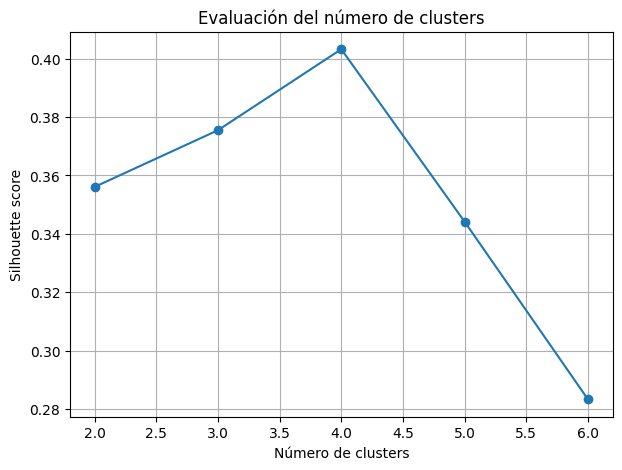

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(df_k["k"], df_k["silhouette"], marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Evaluación del número de clusters")
plt.grid(True)
plt.show()

In [ ]:
k_optimo = 4

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_scaled)

display(df[["Nombre_Completo", "Cluster"]].sort_values("Cluster"))

,Nombre_Completo,Cluster
1,Albacete,0
2,Alicante/Alacant,0
3,Almería,0
5,Badajoz,0
12,Ciudad Real,0
11,Castellón/Castelló,0
10,Cádiz,0
9,Cáceres,0
13,Córdoba,0
22,Jaén,0


1. El primer grupo agrupa principalmente provincias del sur y del litoral mediterráneo caracterizadas por mayores niveles de desempleo y menores valores relativos de renta y PIB per cápita. En este conjunto aparecen provincias como Jaén, Córdoba, Granada, Cádiz, Huelva, Almería, Murcia o Badajoz. Aunque presentan situaciones internas diversas, comparten un perfil asociado a una mayor vulnerabilidad socioeconómica.

2. El segundo grupo está formado exclusivamente por Ceuta y Melilla. Sus características demográficas, económicas y territoriales difieren significativamente del resto de provincias españolas, lo que provoca su aislamiento en una categoría propia dentro del proceso de agrupamiento.

3. El tercer grupo reúne provincias con elevados niveles de desarrollo económico y bienestar. En él se integran Madrid, las provincias vascas, Navarra, Barcelona, Girona, Lleida, Tarragona y Baleares, junto con algunas provincias del valle del Ebro. Este conjunto presenta los mayores niveles de renta y PIB per cápita del análisis y concentra varios de los principales polos económicos del país.

4. El cuarto grupo está compuesto principalmente por provincias del interior y del noroeste peninsular caracterizadas por elevados niveles de envejecimiento y dependencia demográfica. Entre ellas destacan Zamora, Ourense, Lugo, León, Salamanca, Soria, Teruel, Ávila o Palencia. Estas provincias presentan densidades de población reducidas y constituyen algunos de los casos más representativos de los procesos de envejecimiento y despoblación territorial observados en España.

In [ ]:
# Interpretación clusters
perfil_clusters = df.groupby("Cluster")[cols_modelo].mean()
display(perfil_clusters)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Cluster,,,,,,,
0,13.915000,19.722000,32801.950000,24353.050000,51.870000,124.872000,83.171500
1,24.590000,13.185000,45448.000000,21433.500000,48.980000,5716.965000,82.130000
2,7.859167,21.065000,41968.916667,36923.916667,54.753333,281.040000,84.320833
3,8.371111,26.864444,34108.166667,29226.111111,63.467778,53.029444,84.251667


In [ ]:
df_scaled_clusters = df_scaled.copy()
df_scaled_clusters["Cluster"] = df["Cluster"].values

perfil_clusters_scaled = df_scaled_clusters.groupby("Cluster").mean()
display(perfil_clusters_scaled)

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Cluster,,,,,,,
0,0.680913,-0.580873,-0.615641,-0.812600,-0.674190,-0.200447,-0.694195
1,3.182235,-2.081204,1.933620,-1.342691,-1.100645,4.753877,-1.901058
2,-0.738065,-0.272636,1.232287,1.469841,-0.248718,-0.062090,0.637623
3,-0.618108,1.058416,-0.352326,0.072182,1.037206,-0.264096,0.557474


## Visualización de clusters

Una vez obtenidas las tipologías territoriales mediante K-Means, se representa su distribución espacial sobre un mapa de comunidades autónomas. Para ello se utiliza GeoPandas, que permite trabajar con datos geográficos en formato GeoJSON y unirlos con los resultados del análisis.

In [ ]:
!pip install geopandas

Se carga un archivo GeoJSON con las geometrías de provincias españolas. Este archivo contiene los polígonos necesarios para representar cada territorio en un mapa.

El conjunto geográfico utilizado procede del repositorio abierto `click_that_hood`, que proporciona geometrías administrativas en formato GeoJSON para distintos países y regiones.

In [ ]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson"

gdf = gpd.read_file(url)

gdf.head()

,cod_prov,name,cod_ccaa,cartodb_id,created_at,updated_at,geometry
0,07,Illes Balears,03,7,2014-09-30 00:00:00+00:00,2014-12-25 01:56:10+00:00,"MULTIPOLYGON (((3.21364 39.95751, 3.1544 39.92..."
1,33,Asturias,18,33,2014-09-30 00:00:00+00:00,2014-12-25 01:56:10+00:00,"MULTIPOLYGON (((-5.84083 43.66062, -5.83002 43..."
2,15,A Coruña,11,15,2014-09-30 00:00:00+00:00,2014-12-25 01:56:10+00:00,"MULTIPOLYGON (((-7.6803 43.78714, -7.66231 43...."
3,17,Girona,08,17,2014-09-30 00:00:00+00:00,2014-12-25 01:56:10+00:00,"MULTIPOLYGON (((1.74871 42.49482, 1.82355 42.4..."
4,35,Las Palmas,04,35,2014-09-30 00:00:00+00:00,2014-12-25 01:56:10+00:00,"MULTIPOLYGON (((-13.89051 28.75685, -13.83632 ..."


Antes de unir los resultados del clustering con el mapa, se revisan los nombres de las provincias incluidos en el GeoJSON. Esta comprobación es necesaria porque los nombres pueden no coincidir exactamente con los utilizados en las tablas del INE.

In [ ]:
print(gdf.columns)

gdf["name"]

Index(['cod_prov', 'name', 'cod_ccaa', 'cartodb_id', 'created_at',
       'updated_at', 'geometry'],
      dtype='object')


,name
0,Illes Balears
1,Asturias
2,A Coruña
3,Girona
4,Las Palmas
5,Pontevedra
6,Santa Cruz De Tenerife
7,Cantabria
8,Málaga
9,Almería


Se crea una tabla auxiliar que contiene únicamente el nombre normalizado de cada provincia y el cluster asignado por el algoritmo K-Means. Esta tabla será utilizada para unir los resultados del análisis con la geometría territorial.

In [ ]:
cluster_df = df[["Nombre_Completo", "Cluster"]].copy()

Los nombres de las provincias no coinciden exactamente entre el dataset analítico y el archivo GeoJSON. Estas diferencias se deben principalmente a variaciones lingüísticas, cambios en el orden de los topónimos bilingües y diferencias de nomenclatura entre las fuentes estadísticas y geográficas.

Por este motivo, se define un diccionario de equivalencias que permite armonizar los nombres utilizados en ambas fuentes antes de realizar la unión espacial. Este proceso garantiza que cada provincia quede correctamente asociada a su geometría correspondiente dentro del mapa.

In [ ]:
equivalencias = {
    "Balears, Illes": "Illes Balears",
    "Coruña, A": "A Coruña",
    "Palmas, Las": "Las Palmas",
    "Rioja, La": "La Rioja",

    "Alicante/Alacant": "Alacant/Alicante",
    "Castellón/Castelló": "Castelló/Castellón",
    "Valencia/València": "València/Valencia",

    "Bizkaia": "Bizkaia/Vizcaya",
    "Gipuzkoa": "Gipuzkoa/Guipúzcoa",

    "Santa Cruz de Tenerife": "Santa Cruz De Tenerife"
}

cluster_df["Mapa"] = cluster_df["Nombre_Completo"].replace(equivalencias)

Una vez armonizados los nombres, se realiza una unión entre el GeoJSON de provincias y la tabla de clusters. El resultado es un GeoDataFrame que contiene tanto la geometría de cada territorio como la tipología asignada por el modelo de clustering.

In [ ]:
gdf_merge = gdf.merge(
    cluster_df,
    left_on="name",
    right_on="Mapa",
    how="left"
)

La tabla resultante permite comprobar que cada provincia ha sido asociada correctamente con su cluster correspondiente. Esta verificación evita errores en la representación cartográfica derivados de problemas de nomenclatura.

In [ ]:
gdf_merge[["name","Cluster"]]

,name,Cluster
0,Illes Balears,2
1,Asturias,3
2,A Coruña,3
3,Girona,2
4,Las Palmas,0
5,Pontevedra,3
6,Santa Cruz De Tenerife,0
7,Cantabria,3
8,Málaga,0
9,Almería,0


In [ ]:
gdf_merge[gdf_merge["Cluster"].isna()][["name"]]

,name


Finalmente, se representa el resultado del clustering sobre el mapa de España. Cada color corresponde a uno de los grupos identificados por K-Means, permitiendo observar la distribución espacial de las tipologías territoriales obtenidas.

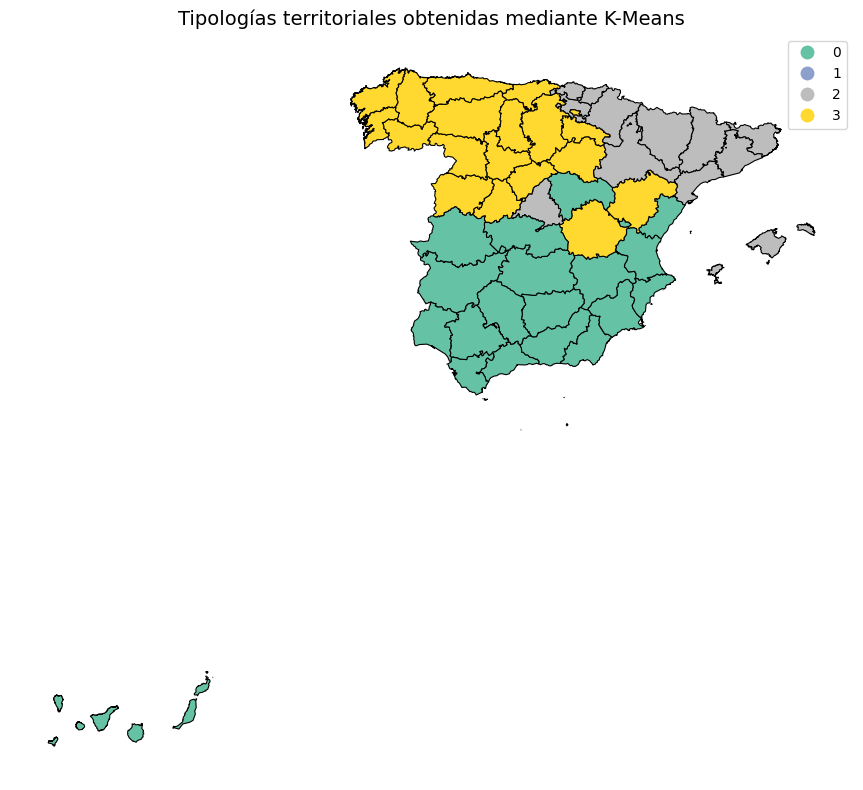

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Colores personalizados:
# Cluster 0 -> verde
# Cluster 1 -> azul
# Cluster 2 -> gris
# Cluster 3 -> amarillo
cmap = ListedColormap([
    "#66c2a5",  # 0
    "#8da0cb",  # 1
    "#bdbdbd",  # 2 (gris)
    "#ffd92f"   # 3 (amarillo)
])

fig, ax = plt.subplots(figsize=(10,8))

gdf_merge.plot(
    column="Cluster",
    categorical=True,
    cmap=cmap,
    #cmap="Set2",
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    ax=ax
)

ax.set_title(
    "Tipologías territoriales obtenidas mediante K-Means",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

El mapa muestra una distribución territorial coherente con los patrones observados previamente mediante el PCA y el análisis de clusters.

- El **cluster 0** se concentra principalmente en el sur peninsular, parte de Castilla-La Mancha, Murcia, la Comunidad Valenciana y las provincias canarias. Este grupo se caracteriza por mayores niveles de desempleo y menores valores relativos de renta y PIB per cápita, configurando un perfil asociado a una mayor vulnerabilidad socioeconómica.
- El **cluster 2** reúne las provincias con mayores niveles de desarrollo económico y bienestar. Se localiza principalmente en Madrid, las provincias vascas, Navarra, Cataluña, Baleares y parte del valle del Ebro. Estas provincias presentan los valores más elevados de renta y PIB per cápita, junto con menores niveles de desempleo.
- El **cluster 3** agrupa gran parte de las provincias del interior y del noroeste peninsular. Este conjunto se caracteriza por elevados niveles de envejecimiento, mayores tasas de dependencia y densidades de población reducidas, constituyendo el perfil más próximo a los procesos de despoblación y envejecimiento territorial.

Finalmente, Ceuta y Melilla forman un cluster independiente debido a sus características demográficas, económicas y territoriales singulares, que las diferencian claramente del resto de provincias españolas.

Resulta especialmente significativo que provincias habitualmente asociadas al debate sobre la despoblación, como **Soria, Teruel, Zamora u Ourense**, aparezcan agrupadas en el cluster demográfico, mientras que **Jaén** se integra en el cluster de vulnerabilidad socioeconómica junto a otras provincias del sur peninsular. Este resultado refuerza la idea de que **los desequilibrios territoriales en España responden a problemáticas diversas** que no pueden explicarse únicamente mediante la despoblación.

# Análisis de robustez: exclusión de Ceuta y Melilla

Con el objetivo de evaluar la estabilidad de los patrones territoriales obtenidos, se realiza una prueba de robustez excluyendo temporalmente las ciudades autónomas de Ceuta y Melilla.

Estas presentan características demográficas y socioeconómicas diferenciadas respecto al resto de provincias españolas, especialmente en variables como la densidad de población, el desempleo y determinados indicadores económicos.

El análisis permite comprobar si la estructura identificada mediante PCA y clustering se mantiene estable tras eliminar estas observaciones singulares o si, por el contrario, los resultados dependen excesivamente de su presencia.

In [ ]:
df_robustez = df[~df["Nombre_Completo"].isin(["Ceuta", "Melilla"])].copy()

print("Número de territorios:", len(df_robustez))

display(df_robustez[["Nombre_Completo"]])

Número de territorios: 50


,Nombre_Completo
0,Araba/Álava
1,Albacete
2,Alicante/Alacant
3,Almería
4,Ávila
5,Badajoz
6,"Balears, Illes"
7,Barcelona
8,Burgos
9,Cáceres


In [ ]:
X_robustez = df_robustez[cols_modelo]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_robustez = StandardScaler()

X_robustez_scaled = scaler_robustez.fit_transform(X_robustez)

X_robustez_scaled = pd.DataFrame(
    X_robustez_scaled,
    columns=cols_modelo,
    index=df_robustez["Nombre_Completo"]
)

display(X_robustez_scaled.head())

,Paro_medio,Porcentaje_Mayores_65,Renta_Media_Hogar,PIB_Per_Capita,Tasa_Dependencia,Densidad_Poblacion,Esperanza_Vida
Nombre_Completo,,,,,,,
Araba/Álava,-0.972928,0.058036,1.381146,2.336225,0.348006,-0.132430,1.466831
Albacete,0.251499,-0.439630,-0.615829,-0.487595,-0.495716,-0.611504,-0.218327
Alicante/Alacant,0.608996,-0.409919,-0.850175,-1.033014,-0.314494,1.181338,-0.280281
Almería,1.011180,-1.561237,-0.972600,-0.928702,-1.086916,-0.269855,-2.151302
Ávila,-0.472432,1.132600,-1.139194,-1.081841,1.249659,-0.645985,0.760551


Al igual que en el análisis provincial completo, se aplica un Análisis de Componentes Principales (PCA) sobre los datos normalizados con el fin de reducir la dimensionalidad y sintetizar la información contenida en las variables originales.

Posteriormente se compara la varianza explicada con la obtenida en el análisis completo para comprobar la estabilidad de la estructura interna de los datos.

In [ ]:
from sklearn.decomposition import PCA

pca_robustez = PCA()

X_pca_robustez = pca_robustez.fit_transform(X_robustez_scaled)

varianza_robustez = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca_robustez.explained_variance_ratio_))],
    "Varianza_explicada": pca_robustez.explained_variance_ratio_,
    "Varianza_acumulada": pca_robustez.explained_variance_ratio_.cumsum()
})

display(varianza_robustez)

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.467359,0.467359
1,PC2,0.360033,0.827393
2,PC3,0.080062,0.907455
3,PC4,0.051053,0.958508
4,PC5,0.027148,0.985656
5,PC6,0.010990,0.996646
6,PC7,0.003354,1.000000


Se comparan los resultados del PCA original y del PCA sin Ceuta y Melilla para comprobar si la estructura de los componentes principales se mantiene estable tras eliminar dichas observaciones.

In [ ]:
print("PCA original")
display(varianza.head(3))

print("PCA sin Ceuta y Melilla")
display(varianza_robustez.head(3))

PCA original


,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.496735,0.496735
1,PC2,0.289616,0.786351
2,PC3,0.135323,0.921673


PCA sin Ceuta y Melilla


,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.467359,0.467359
1,PC2,0.360033,0.827393
2,PC3,0.080062,0.907455


La comparación entre ambos análisis muestra una elevada estabilidad en la estructura de los componentes principales. Aunque se observan ligeras variaciones en la distribución de la varianza explicada, los dos primeros componentes continúan concentrando más del 80% de la información total.

En particular, la varianza explicada acumulada por los dos primeros componentes pasa del 78,6% al 82,7% tras excluir Ceuta y Melilla, mientras que la representación global de los datos mediante tres componentes continúa superando el 90% de la varianza total.

Estos resultados sugieren que las principales dimensiones identificadas en el análisis provincial no dependen de la presencia de las ciudades autónomas, sino que reflejan patrones territoriales estables presentes en el conjunto de provincias españolas.

Una vez comprobada la estabilidad de la estructura del PCA, se evalúan diferentes configuraciones del algoritmo K-Means mediante el coeficiente de Silhouette. El objetivo es determinar si la exclusión de Ceuta y Melilla modifica significativamente el número óptimo de grupos o la estructura general de las tipologías territoriales identificadas previamente.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_robustez = []

for k in range(2,7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_robustez_scaled)

    score = silhouette_score(
        X_robustez_scaled,
        labels
    )

    resultados_robustez.append({
        "k": k,
        "silhouette": score
    })

df_robustez_k = pd.DataFrame(resultados_robustez)

display(df_robustez_k)

,k,silhouette
0,2,0.341812
1,3,0.379980
2,4,0.345485
3,5,0.277658
4,6,0.259074


La evaluación mediante el coeficiente de Silhouette muestra que, una vez excluidas Ceuta y Melilla, la configuración óptima pasa a ser de tres grupos, alcanzando un valor de 0,380.

Este resultado es coherente con el análisis principal, donde las ciudades autónomas formaban un cluster independiente debido a sus características diferenciadas. Al eliminarlas del conjunto de datos, desaparece dicho grupo específico y la estructura territorial queda representada mediante tres grandes tipologías provinciales.

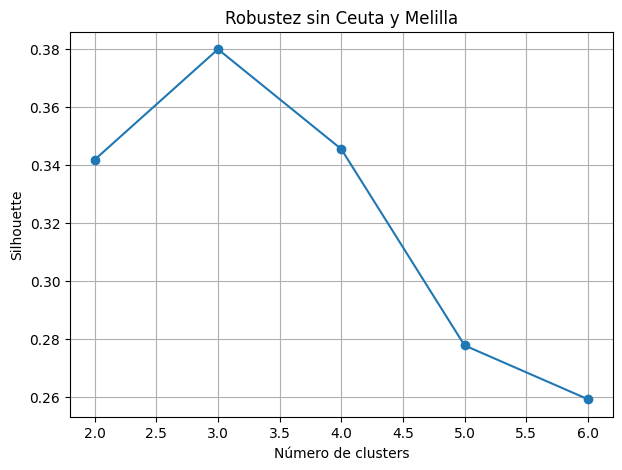

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    df_robustez_k["k"],
    df_robustez_k["silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.title("Robustez sin Ceuta y Melilla")

plt.grid(True)

plt.show()

Una vez identificado el número óptimo de grupos, se aplica nuevamente el algoritmo K-Means para obtener las tipologías territoriales resultantes y compararlas con las obtenidas en el análisis principal.

In [ ]:
kmeans_robustez = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_robustez["Cluster"] = kmeans_robustez.fit_predict(
    X_robustez_scaled
)

display(
    df_robustez[
        ["Nombre_Completo","Cluster"]
    ].sort_values("Cluster")
)

,Nombre_Completo,Cluster
0,Araba/Álava,0
7,Barcelona,0
6,"Balears, Illes",0
16,Girona,0
27,Madrid,0
30,Navarra,0
19,Gipuzkoa,0
47,Bizkaia,0
21,Huesca,1
23,León,1


Los resultados obtenidos muestran una elevada estabilidad respecto al análisis principal.

1. El primer grupo reúne las provincias con mayores niveles de desarrollo económico, incluyendo Madrid, las provincias vascas, Navarra, Barcelona, Girona y Baleares. Este conjunto coincide esencialmente con el cluster de mayor renta y PIB per cápita identificado anteriormente.

2. El segundo grupo agrupa principalmente provincias del interior y del noroeste peninsular caracterizadas por elevados niveles de envejecimiento, dependencia demográfica y baja densidad de población. Entre ellas destacan Zamora, Ourense, Lugo, León, Soria, Teruel o Salamanca.

3. El tercer grupo concentra provincias con mayores dificultades económicas y laborales relativas, incluyendo Jaén, Córdoba, Granada, Cádiz, Huelva, Badajoz, Murcia y buena parte del litoral mediterráneo.

La comparación con el análisis original muestra que la estructura general de los grupos permanece prácticamente inalterada. La única diferencia relevante es la desaparición del cluster específico formado por Ceuta y Melilla, que queda absorbido al excluir dichas observaciones.

In [ ]:
cluster_df_rob = df_robustez[
    ["Nombre_Completo","Cluster"]
].copy()

equivalencias = {
    "Balears, Illes": "Illes Balears",
    "Coruña, A": "A Coruña",
    "Palmas, Las": "Las Palmas",
    "Rioja, La": "La Rioja",

    "Alicante/Alacant": "Alacant/Alicante",
    "Castellón/Castelló": "Castelló/Castellón",
    "Valencia/València": "València/Valencia",

    "Bizkaia": "Bizkaia/Vizcaya",
    "Gipuzkoa": "Gipuzkoa/Guipúzcoa",

    "Santa Cruz de Tenerife": "Santa Cruz De Tenerife"
}

cluster_df_rob["Mapa"] = cluster_df_rob[
    "Nombre_Completo"
].replace(equivalencias)

gdf_rob = gdf.merge(
    cluster_df_rob,
    left_on="name",
    right_on="Mapa",
    how="left"
)

La siguiente figura muestra la distribución geográfica de los grupos obtenidos tras excluir Ceuta y Melilla. Esto permite visualizar de forma intuitiva si la estructura territorial detectada se mantiene estable respecto al análisis inicial.

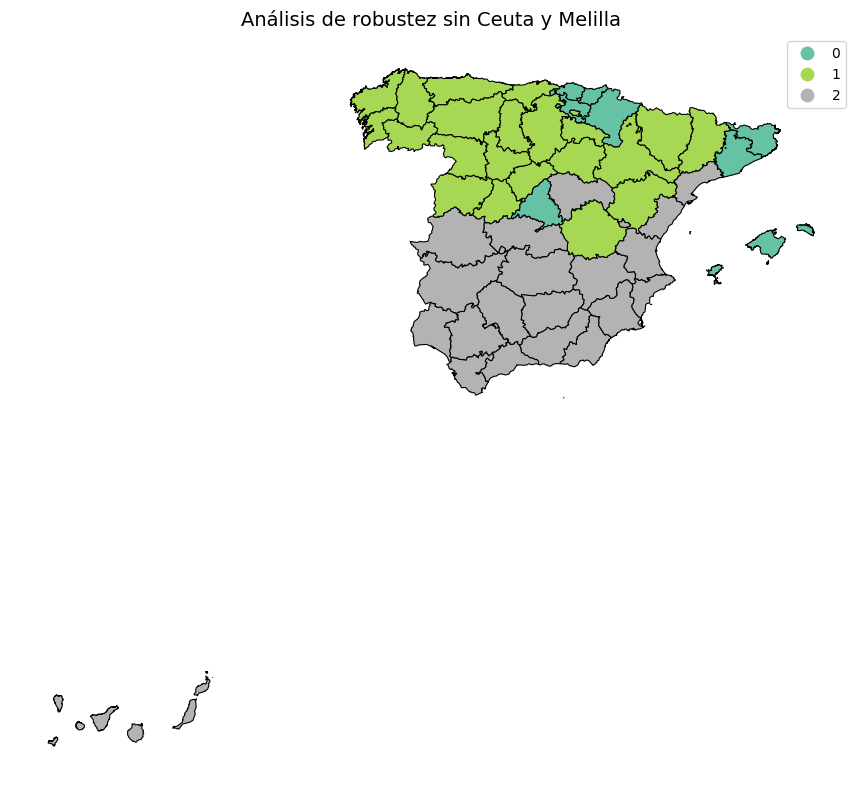

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,8))

gdf_rob["Cluster"] = gdf_rob["Cluster"].astype("Int64")

gdf_rob.plot(
    column="Cluster",
    categorical=True,
    cmap="Set2",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Análisis de robustez sin Ceuta y Melilla",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

La representación espacial obtenida tras excluir Ceuta y Melilla muestra una distribución territorial muy similar a la observada en el análisis principal. Los tres grandes perfiles identificados previamente continúan apareciendo de forma claramente diferenciada: un grupo asociado a provincias del sur con mayores dificultades económicas, un conjunto de provincias del interior y del noroeste caracterizadas por el envejecimiento demográfico y un grupo formado por los principales polos de desarrollo económico del país.

La principal diferencia observada es la desaparición del cluster específico correspondiente a Ceuta y Melilla, lo que confirma que estas ciudades autónomas actuaban como observaciones singulares dentro del conjunto analizado.